In [107]:
# This notebook is to plot the conditions for forks
# There are two conditions saved in the file and they both have to be zero
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [108]:
fdir1 = "output/r=2.500000phi= 0.000000/condensed-ldos-k0.tsv"
df1 = pd.read_csv(fdir1, sep="\t", header=None, dtype=np.double, skiprows=3)
head1 = pd.read_csv(fdir1, sep="\t", nrows=1)

fdir2 = "output/r=2.500000phi= 0.000000/condensed-ldos-k1.tsv"
df2 = pd.read_csv(fdir2, sep="\t", header=None, dtype=np.double, skiprows=3)
head2 = pd.read_csv(fdir2, sep="\t", nrows=1)

fdir3 = "output/r=2.500000phi= 0.000000/condensed-ldos-k2.tsv"
df3 = pd.read_csv(fdir3, sep="\t", header=None, dtype=np.double, skiprows=3)
head3 = pd.read_csv(fdir3, sep="\t", nrows=1)

nx, ny, dx, dy, sx, sy, sep, idk1, idk2 = head1.iloc[0].tolist()

In [109]:
Z = df1.to_numpy() + df2.to_numpy() + df3.to_numpy()
xlin = np.linspace(-sx, sx, int(nx))
ylin = np.linspace(-sy, sy, int(ny))
X, Y = np.meshgrid(xlin, ylin)

In [110]:
sep

20.0

In [111]:
# We create a mask because our functions blow up at r -> zero
xa = 2.5
ya = 0

maskr = 0.1
mask1 = ((X+xa) ** 2 + (Y+ya) ** 2) <= maskr**2
mask2 = ((X-xa) ** 2 + (Y-ya) ** 2) <= maskr**2

mask = mask1 | mask2

Z_masked = Z
Z_masked[mask] = 0

ZR = np.square(Z_masked * 2*((X+xa) ** 2 + (Y+ya) ** 2 + (X-xa) ** 2 + (Y-ya) ** 2))
#ZR = Z_masked

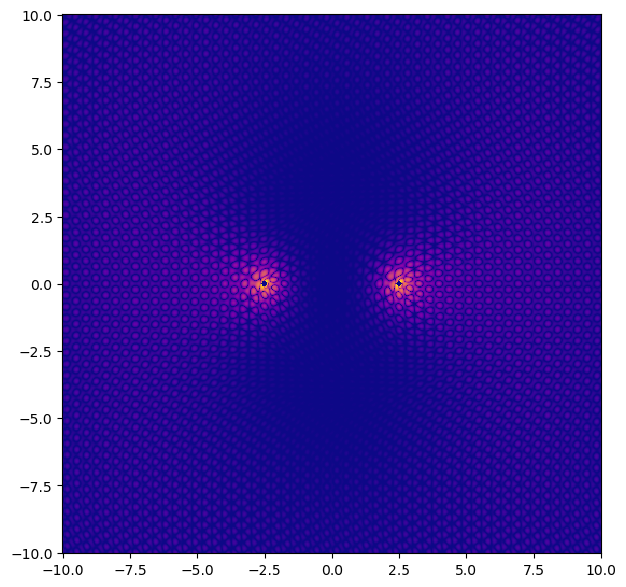

In [112]:
fig1, ax1 = plt.subplots(figsize=(7, 7))

ax1.pcolormesh(X, Y, np.log(ZR+1), cmap="plasma")
#ax1.pcolormesh(X, Y, np.abs(Zc2), cmap="Greys_r", alpha=0.5)
ax1.set_aspect("equal")

In [113]:
Z_norm = (ZR - ZR.min()) / (ZR.max() - ZR.min())
Z_img = (Z_norm * 255).astype(np.uint8)

In [114]:
from PIL import Image
from matplotlib import cm
import matplotlib.colors as mcolors

In [115]:
#img = Image.fromarray(Z_img)
#img.save("heightmap.png")
Z16 = (Z_norm * 65535).astype(np.uint16)
Image.fromarray(Z16).save("heightmap16_s.png")

In [ ]:
cmap = cm.plasma   # or any cmap
rgba = cmap(Z_norm)          # (nx, ny, 4)

rgb = (rgba[:, :, :3] * 255).astype(np.uint8)

Image.fromarray(rgb, mode="RGB").save("colormap.png")

In [117]:
Image.open("colormap_16bit.png").mode

'RGB'